In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Q_DIR is one folder up where the question images sit
Q_DIR    = os.path.normpath(os.path.join(os.getcwd(), '..', 'question'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# load the image and convert to LAB color space
# LAB keeps color (a, b) and brightness (L) separate,
# so we can touch only the brightness without messing up hue
img_bgr = cv2.imread(os.path.join(Q_DIR, 'sapphire.jpg'))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

lab     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

In [3]:
# apply gamma = 0.45 only to the L channel
# this mimics a monitor gamma correction - brightens without shifting colors
L_norm = L.astype(np.float64) / 255.0
gamma  = 0.45
L_corr = np.power(L_norm, gamma)
L_corr = (L_corr * 255).astype(np.uint8)

# put the corrected L back with the original a and b, then convert to RGB
lab_corr = cv2.merge([L_corr, a, b])
result   = cv2.cvtColor(lab_corr, cv2.COLOR_LAB2RGB)

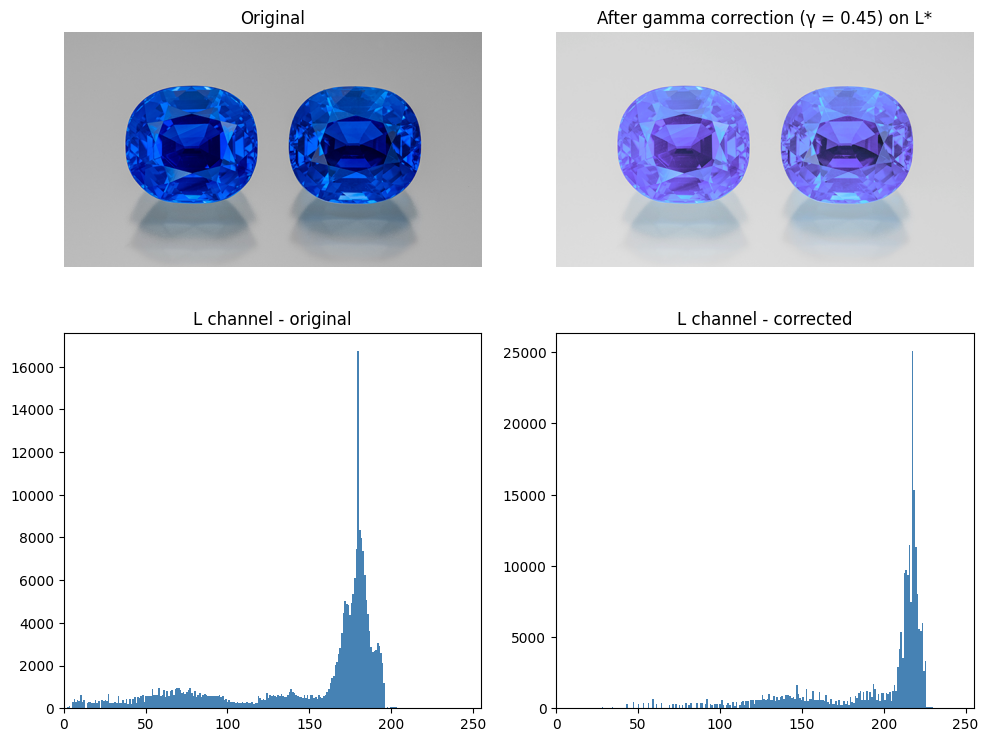

In [4]:
# top row: before and after images
# bottom row: L channel histograms to show how brightness shifted
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(result)
axes[0, 1].set_title(f'After gamma correction (γ = {gamma}) on L*')
axes[0, 1].axis('off')

axes[1, 0].hist(L.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[1, 0].set_title('L channel - original')
axes[1, 0].set_xlim([0, 255])

axes[1, 1].hist(L_corr.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[1, 1].set_title('L channel - corrected')
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q2_lab_gamma.png'), dpi=150)
plt.show()